*******

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
G1 = nx.Graph()

#### gen topologies funcs

In [3]:
def base_circ(node_number):
    G1.add_nodes_from(range(1,node_number + 1))
    for i in range(0,node_number):
        G1.add_edge(i+1,(i+2)%node_number + 1)
        G1.add_edge(i+1,(i+3)%node_number + 1)
    

In [4]:
#ordinary circle
def single_circ(node_number):
    G1.add_nodes_from(range(1,node_number + 1))
    for i in range(0,node_number):
        G1.add_edge(i+1,(i+1)%node_number + 1)
        #G1.add_edge(i_number+1,(i_number+3)%node_number + 1)
    

In [5]:
#2d-mesh (rect)
def mesh_2D(node_number, width):
    step = width - 1
    for i in range(0,int(node_number/width)):
        for j in range(0,step):
            a = i*width + (j+1)
            b = i*width + (j+1) + 1
            G1.add_edge(a, b)
            #G1.add_edge(i*width + (j+1),i*width + (j+1) + 1)
            #print(i*width + (j+1), i*width + (j+1) + 1, i,j)
    #'''
    print("check")
    
    for i in range(0,width):
        for j in range(0,int(node_number/width) - 1):
            a = j*width+1 + i
            b = (j+1)*width + 1 + i
            G1.add_edge(a, b)
            #print(a, b, i,j)
            
    #''' 

In [6]:
def thorus(node_number,width):
    step = width - 1
    mesh_2D(node_number,width)
    
    for i in range(0,int(node_number/width)):
        a = i*width +1
        b = i*width + width
        G1.add_edge(a, b)
        #print(a,b,i)
        
    print("check")
        
    for i in range(0,int(width)):
        a = i + 1
        b = step*width + 1 + i 
        G1.add_edge(a, b)
        #print(a,b,i)

In [7]:
def hypercube_2D(node_number):
    step  = 4
    
    offset = 0
    

    #squares
    for i in range(0,int(node_number / 4)):
        a = i*step + offset
        G1.add_edge(a, a+1)
        G1.add_edge(a+1, a+2)
        G1.add_edge(a+2, a+3)
        G1.add_edge(a+3, a)
    
    print("check")
    
    #connect squares by dioganale
    for i in range(0,int(node_number / 4) - 1):
        a = i*step + offset
        G1.add_edge(a,   a   + 4)
        G1.add_edge(a+1, a+1 + 4)
        G1.add_edge(a+2, a+2 + 4)
        G1.add_edge(a+3, a+3 + 4)
    
    #from end to center
    a  = offset
    b  = step* (int(node_number / 4) - 2) + 4 + offset
    G1.add_edge(a,   b)
    G1.add_edge(a+1, b+1)
    G1.add_edge(a+2, b+2)
    G1.add_edge(a+3, b+3)
    
  
    

In [8]:
def WK_recursive(L): #W = 4
    W = 4
    offset = 0
    node_value = W**L
    
    bias = 0  
    
    #add nodes
    G1.add_nodes_from(range(offset,node_value + offset))
    
    for i in range(offset,node_value + offset): print(str(i) + " " + "("+str(int(i/4))+","+str(int(i%4)) +")")
    
    #add square edges
    for i in range(0,4**(L-1)):
        G1.add_edge(0 + bias,   1 + bias)
        G1.add_edge(1 + bias,   2 + bias)
        G1.add_edge(2 + bias,   3 + bias)
        G1.add_edge(3 + bias,   0 + bias)
        
        #G1.add_edge(0 + bias,   2 + bias)
        #G1.add_edge(1 + bias,   3 + bias)
        
        bias += 4
    
    f1 = 0 
    f2 = 1
    
    #add edge_circle
    for i in range(0,4**(L-1)):
        n1 = f1*4 + f2
        n2 = f2*4 + f1
        G1.add_edge(n1, n2) 
        
        f1, f2 = f2, f1
        
        f2 += 2
        f2 %= 4
        
        G1.add_edge(n2, f1*4 + f2) 
        
    #add diagonals   
    for i in range(0,4**(L-1)):
        f1 = 2*(int(i/2)%2)
        f2 = 2*int(i%2)
        n1 = f1*4 + f2
        f1 = 2*(int((i+1)/2)%2)
        f2 = 2*int((i+1)%2)
        n2 = f1*4 + f2
        G1.add_edge(n1,n2)
        
        f1 = 2*(int(i/2)%2)+1
        f2 = 2*int(i%2)+1
        n1 = f1*4 + f2
        f1 = 2*(int((i+1)/2)%2)+1
        f2 = 2*int((i+1)%2)+1
        n2 = f1*4 + f2
        G1.add_edge(n1,n2)
    

#### layout_funcs

In [9]:
def mesh_layout(node_number,width,offset):
    pos = {(i+offset):(int(i%width),int(i/width)) for i in range(0,node_number)}
    return pos 

In [10]:
def hypercube_layout(node_number):
    pos1 = {}
    pos2 = {}
    
    offset = 0
    
    n_n = node_number
    
    '''
    for i in range(0,int(n_n /4)):
        pos1[i*4+offset] = (i,i)
        pos1[i*4+1+offset] = (i,int(n_n /2)-i)
    for i in range(0,int(n_n /4)):
        pos2[i*4+2+offset] = (int(n_n /2)-i,i)
        pos2[i*4+3+offset] = (int(n_n /2)-i,int(n_n /2)-i)
    '''
    
    #'''
    for i in range(0,int(n_n /4)):
        pos1[i*4+offset] = (i,i)
        pos1[i*4+1+offset] = (i,int(n_n /2)-i)
    for i in range(0,int(n_n /4)):
        pos2[i*4+2+offset] = (int(n_n /2)-i,int(n_n /2)-i)
        pos2[i*4+3+offset] = (int(n_n /2)-i,i)
    #'''
    
    
        
    #print(i*4+offset,(i,i))
    #print(i*4+1+offset,(i,int(n_n /2)-i))
    #print(i*4+2+offset,(int(n_n /2)-i,int(n_n /2)-i))
    #print(i*4+3+offset,(int(n_n /2)-i,i))
        
    return pos1|pos2

In [11]:
#print(hypercube_layout(node_number))

#### draw func

In [12]:
#Gen Gray code (for hypercube)
n = 4

gray_ar = []

for i in range(0, 1<<n):
        gray=i^(i>>1)
        s = "{0:0{1}b}".format(gray,n)
        gray_ar.append(s)

gray_ar

['0000',
 '0001',
 '0011',
 '0010',
 '0110',
 '0111',
 '0101',
 '0100',
 '1100',
 '1101',
 '1111',
 '1110',
 '1010',
 '1011',
 '1001',
 '1000']

In [13]:
def draw_topology(pos,offset,a_offset):
    #pos = nx.circular_layout(G1)
    
    
    #labs = {a+a_offset: "r{}".format(a)+"("+str(int(a/4))+","+str(int(a%4)) +")" for a in range(offset,node_number+offset)}
    
    #simple label
    #labs = {a+a_offset: "r{}".format(a) for a in range(offset,node_number+offset)}
    labs = {a+a_offset: "R" for a in range(offset,node_number+offset)}

    #gray label
    #labs = {a+a_offset:gray_ar[a] for a in range(offset,node_number+offset)}
    
    #for i in range(offset,node_value + offset): print(str(i) + " " + "("+str(int(i/4))+","+str(int(i%4)) +")")
    
    #labs = {a: "r{} ({},{})".format(a-1,4*int((a-1)%4),4*int((a-1)/4)) for a in range(1,node_number + 1)}
    f = plt.figure()
    f.set_figwidth(8)
    f.set_figheight(8)

    node_opts = {"node_size": 2500, "node_color": '#ffffff', "edgecolors": "k", "linewidths": 5.0, "node_shape": "s"}
    nx.draw_networkx_nodes(G1, pos, **node_opts)

    #ffc966

    nx.draw_networkx(G1,pos = pos,font_size = 37,labels = labs,linewidths = 3,node_color = '#ffffff', 
                      edge_color = '#000000',width = 3.5, font_family ='Segoe UI')

In [14]:
#Improve layout

''' 
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

G.add_edges_from([(1,2),(2,3),(2,4),(3,5),(5,6),(5,7)])

pos = {1: (0,0), 2: (1,1), 3: (0,2), 4: (2,1), 5: (3,2), 6: (4,1), 7: (3,0)}

nx.draw(G, pos, with_labels=True)
plt.show()

'''

' \nimport networkx as nx\nimport matplotlib.pyplot as plt\n\nG = nx.Graph()\n\nG.add_edges_from([(1,2),(2,3),(2,4),(3,5),(5,6),(5,7)])\n\npos = {1: (0,0), 2: (1,1), 3: (0,2), 4: (2,1), 5: (3,2), 6: (4,1), 7: (3,0)}\n\nnx.draw(G, pos, with_labels=True)\nplt.show()\n\n'

#### parameters_func

In [15]:
def get_topology_parameters():   
    
    N  = len(G1.nodes())                      #Nodes number
    Ed = len(G1.edges())                      #Edges number
    St = [val for (node, val) in G1.degree()] #Nodes degree
    D  = nx.diameter(G1)                      #Graph diameter
    
    #print(N,Ed,St,D)
    
    return (N,Ed,St,D)
    

In [16]:
#get_topology_parameters()

In [17]:
#from networkx.algorithms import community
#community.kernighan_lin_bisection(G1)

***

### main programm

In [18]:
#node_number = 9
node_number = 9

In [19]:
'''
base_circ(node_number)
#single_circ(node_number)

pos = nx.circular_layout(G1)

draw_topology(pos)
'''

'\nbase_circ(node_number)\n#single_circ(node_number)\n\npos = nx.circular_layout(G1)\n\ndraw_topology(pos)\n'

check
{1: (0, 0), 2: (1, 0), 3: (2, 0), 4: (0, 1), 5: (1, 1), 6: (2, 1), 7: (0, 2), 8: (1, 2), 9: (2, 2)}


'\nWK_recursive(2)\n\npos = { 0: (0,0), 3: (0,1), 2: (1,1), 1: (1,0),      + 4: (2,0), 7: (2,1), 6: (3,1), 5: (3,0),      + 8: (2,2), 11: (2,3), 10: (3,3), 9: (3,2),      + 12: (0,2), 15: (0,3), 14: (1,3), 13: (1,2),}\ndraw_topology(pos,0,0)\n'

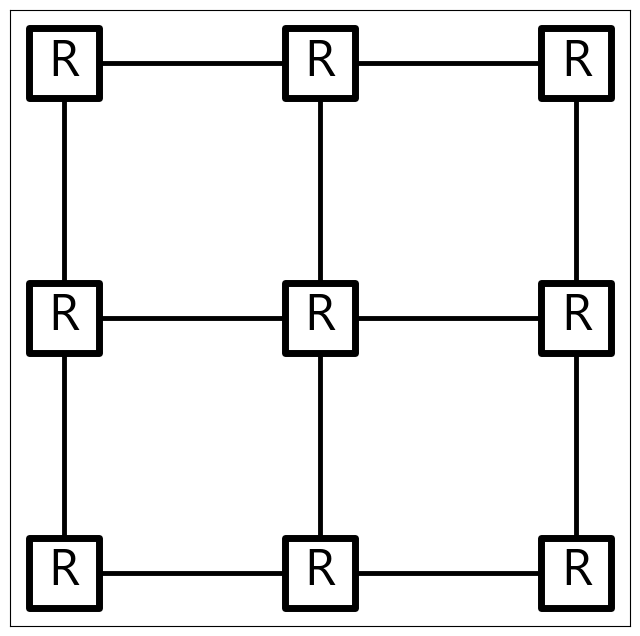

In [20]:
mesh_2D(node_number,3)
#single_circ(node_number)
#thorus(node_number,4)
#hypercube_2D(node_number)


draw_topology(mesh_layout(node_number,3,1),0,1)
print(mesh_layout(node_number,3,1))
#draw_topology(hypercube_layout(node_number),0,0)

'''
WK_recursive(2)

pos = { 0: (0,0), 3: (0,1), 2: (1,1), 1: (1,0),\
      + 4: (2,0), 7: (2,1), 6: (3,1), 5: (3,0),\
      + 8: (2,2), 11: (2,3), 10: (3,3), 9: (3,2),\
      + 12: (0,2), 15: (0,3), 14: (1,3), 13: (1,2),}
draw_topology(pos,0,0)
'''

In [21]:
#get_topology_parameters()

---

In [22]:
G1.nodes()

NodeView((1, 2, 3, 4, 5, 6, 7, 8, 9))

In [23]:
G1.edges()

EdgeView([(1, 2), (1, 4), (2, 3), (2, 5), (3, 6), (4, 5), (4, 7), (5, 6), (5, 8), (6, 9), (7, 8), (8, 9)])

In [24]:
edge_wires = []

for k in G1.nodes():
    ar = []
    for i in G1.edges():
        if i[0] == k: ar.append(i[1])
        if i[1] == k: ar.append(i[0])
    edge_wires.append(ar)
    print(ar)
    
edge_wires

[2, 4]
[1, 3, 5]
[2, 6]
[1, 5, 7]
[2, 4, 6, 8]
[3, 5, 9]
[4, 8]
[5, 7, 9]
[6, 8]


[[2, 4],
 [1, 3, 5],
 [2, 6],
 [1, 5, 7],
 [2, 4, 6, 8],
 [3, 5, 9],
 [4, 8],
 [5, 7, 9],
 [6, 8]]

### Thorus wire gen

In [25]:
#Thorus wires gen

edge_wires = [[] for i in range(0,node_number)]

width = 4
index = 0

for i in edge_wires:
    i.append((width + index)%node_number)
    i.append((node_number - width + index)%node_number)
    i.append((width + index-1)%width+width*int(index/width))
    i.append((width + index-3)%width+width*int(index/width))
    
    index += 1

edge_wires 

[[4, 5, 3, 1],
 [5, 6, 0, 2],
 [6, 7, 1, 3],
 [7, 8, 2, 0],
 [8, 0, 7, 5],
 [0, 1, 4, 6],
 [1, 2, 5, 7],
 [2, 3, 6, 4],
 [3, 4, 11, 9]]

### Hypercube wires gen (how thorus)

Torus and mesh networks, k-ary n-cubes, pack N = kn nodes in a regular n-dimensional grid with k nodes in each dimension and channels between nearest neighbors.
They span a range of networks from rings (n = 1) to binary n-cubes (k = 2), also
know as hypercubes.

In [26]:
edge_wires = [[] for i in range(0,node_number)]

width = 4
index = 0

for i in edge_wires:
    i.append((width + index)%node_number)
    i.append((node_number - width + index)%node_number)
    i.append((width + index-1)%width+width*int(index/width))
    i.append((width + index-3)%width+width*int(index/width))
    
    index += 1

edge_wires 

[[4, 5, 3, 1],
 [5, 6, 0, 2],
 [6, 7, 1, 3],
 [7, 8, 2, 0],
 [8, 0, 7, 5],
 [0, 1, 4, 6],
 [1, 2, 5, 7],
 [2, 3, 6, 4],
 [3, 4, 11, 9]]

---

----

----


## Hypercube 3D

In [27]:
G1 = nx.Graph()

In [28]:
node_number = 16

In [29]:
def hypercube_4D(node_number):
    step  = 4
    
    offset = 0
    
    ar = [0,0,0,0]

    #squares
    #squares
    for i in range(0,int(node_number / 4)):
        a = i*step + offset
        G1.add_edge(a, a+1)
        G1.add_edge(a+1, a+2)
        G1.add_edge(a+2, a+3)
        G1.add_edge(a+3, a)
        
    #connect squares by dioganale    
    for i in range(0,int(node_number / 4)):
        a = i*step + offset
        
        a_ar = [a,a+1,a+2,a+3]
        
        print(a_ar[::-1],ar)
        
        G1.add_edge(a_ar[0],   ar[3])
        G1.add_edge(a_ar[1], ar[2])
        G1.add_edge(a_ar[2], ar[1])
        G1.add_edge(a_ar[3], ar[0])
        
        ar = [a,a+1,a+2,a+3]
    
    #from end to center
    v1 = node_number - 1
    v2 = 0
    G1.add_edge(v1,    v2)
    G1.add_edge(v1-1,v2+1)
    G1.add_edge(v1-2,v2+2)
    G1.add_edge(v1-3,v2+3)
    

        
    G1.remove_edge(0,0)
    G1.remove_edge(0,2)
    
    
    print("check")
    
    


In [30]:
def hypercube_layout_flat(node_number):
    pos1 = {}
    pos2 = {}
    
    offset = 0
    
    n_n = node_number
    
    v1 = 0
    v2 = int(node_number/2)
    
    step = 4
    
    for i in range(0,int(n_n / 4)):
        a = (n_n - i*step) - 1
        
        a_ar = [a,a-1,a-2,a-3]
        if i%2 == 1: a_ar = a_ar[::-1]
        
        pos1[a_ar[0]] = (v1,v1)
        pos1[a_ar[1]] = (v2,v1)
        pos1[a_ar[2]] = (v2,v2)
        pos1[a_ar[3]] = (v1,v2)
        
        print(a)
        
        v1 += 1
        v2 -= 1
        
    return pos1

[3, 2, 1, 0] [0, 0, 0, 0]
[7, 6, 5, 4] [0, 1, 2, 3]
[11, 10, 9, 8] [4, 5, 6, 7]
[15, 14, 13, 12] [8, 9, 10, 11]
check
15
11
7
3


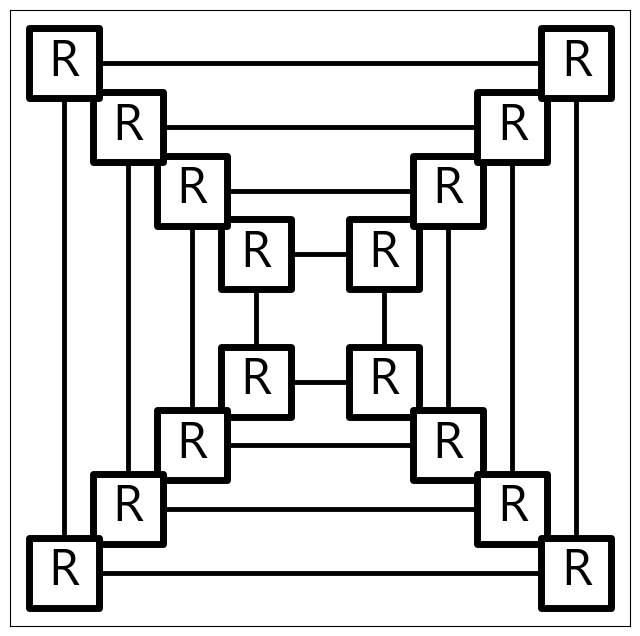

In [31]:
hypercube_4D(node_number)



draw_topology(hypercube_layout_flat(node_number),0,0)

[0, 1, 2, 3]
[7, 6, 5, 4]
[8, 9, 10, 11]
[15, 14, 13, 12]
{0: (0, 0), 1: (1, 0), 2: (2, 0), 3: (3, 0), 7: (0, 1), 6: (1, 1), 5: (2, 1), 4: (3, 1), 8: (0, 2), 9: (1, 2), 10: (2, 2), 11: (3, 2), 15: (0, 3), 14: (1, 3), 13: (2, 3), 12: (3, 3)}


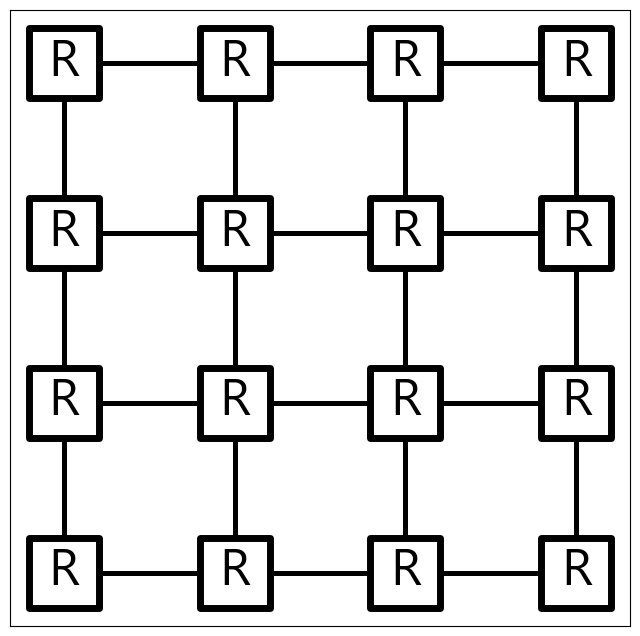

In [32]:
def mesh_layout_for_hypercube(node_number,width,offset):
    
    pos1 = {}
    
    step = 4
    
    for i in range(0,int(node_number / 4)):
        a = i*step
        
        a_ar = [a,a+1,a+2,a+3]
        if i%2 == 1: a_ar = a_ar[::-1]
            
        print(a_ar)
        
        pos1[a_ar[0]] = (0,i)
        pos1[a_ar[1]] = (1,i)
        pos1[a_ar[2]] = (2,i)
        pos1[a_ar[3]] = (3,i)
        
    print(pos1)
    return pos1 

draw_topology(mesh_layout_for_hypercube(node_number,16,0),0,0)


{0: (0, 0), 1: (3, 0), 2: (3, 3), 3: (0, 3), 4: (2, 5), 5: (5, 5), 6: (5, 2), 7: (2, 2), 8: (8, 2), 9: (11, 2), 10: (11, 5), 11: (8, 5), 12: (6, 3), 13: (9, 3), 14: (9, 0), 15: (6, 0)}


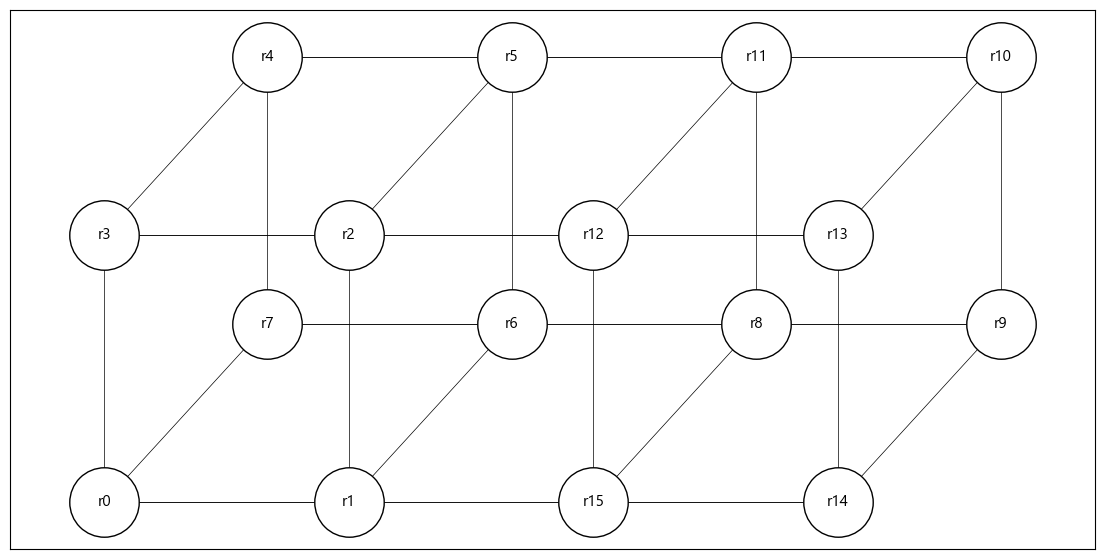

In [33]:
def hypercube_layout_3D(): #only for 16 nodes !!!!!!
    
    pos1 = {}
    
    step = 4
    
    a = 3
    offset = 6
    
    dx = 0
    dy = 0
        
    pos1[0] = (0+dx,0+dy)
    pos1[1] = (a+dx,0+dy)
    pos1[2] = (a+dx,a+dy)
    pos1[3] = (0+dx,a+dy)
    
    dx = 2
    dy = 2
    
    pos1[4] = (0+dx,a+dy)
    pos1[5] = (a+dx,a+dy)
    pos1[6] = (a+dx,0+dy)
    pos1[7] = (0+dx,0+dy)
    
    dx = offset + 2
    dy = 2
        
    pos1[8] = (0+dx,0+dy)
    pos1[9] = (a+dx,0+dy)
    pos1[10] = (a+dx,a+dy)
    pos1[11] = (0+dx,a+dy)
    
    dx = offset
    dy = 0
    
    pos1[12] = (0+dx,a+dy)
    pos1[13] = (a+dx,a+dy)
    pos1[14] = (a+dx,0+dy)
    pos1[15] = (0+dx,0+dy)
    
        
    print(pos1)
    return pos1 

#draw_topology(hypercube_layout_3D(),0,0)

pos = hypercube_layout_3D()

offset = 0
a_offset = 0
#pos = nx.circular_layout(G1)
    
    
#labs = {a+a_offset: "r{}".format(a)+"("+str(int(a/4))+","+str(int(a%4)) +")" for a in range(offset,node_number+offset)}
    
    #simple label
labs = {a+a_offset: "r{}".format(a) for a in range(offset,node_number+offset)}

    #gray label
#labs = {a+a_offset:gray_ar[a] for a in range(offset,node_number+offset)}
    
    #for i in range(offset,node_value + offset): print(str(i) + " " + "("+str(int(i/4))+","+str(int(i%4)) +")")
    
    #labs = {a: "r{} ({},{})".format(a-1,4*int((a-1)%4),4*int((a-1)/4)) for a in range(1,node_number + 1)}
f = plt.figure()
f.set_figwidth(14)
f.set_figheight(7)

node_opts = {"node_size": 2500, "node_color": "w", "edgecolors": "k", "linewidths": 1.0}
nx.draw_networkx_nodes(G1, pos, **node_opts)


nx.draw_networkx(G1,pos = pos,font_size = 11,labels = labs,linewidths = 0.5,node_color = 'w', \
                    edge_color = '#000000',width = 0.5, font_family ='Segoe UI')

[(3, 4), (12, 13), (8, 9), (9, 14), (1, 6), (8, 15), (2, 5), (13, 14), (4, 5), (5, 6), (12, 15), (14, 15), (8, 11), (0, 1), (0, 7), (9, 10), (1, 2), (10, 11), (6, 7), (4, 7), (0, 3), (10, 13), (2, 3), (11, 12)]


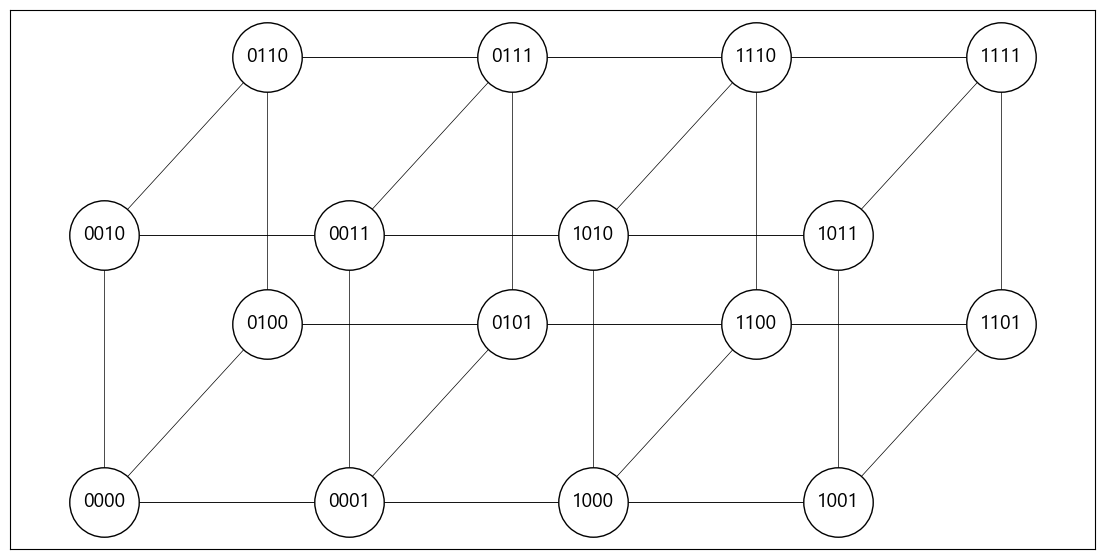

In [34]:
def hypercube_layout_3D(): #only for 16 nodes !!!!!!
    
    pos1 = {}
    
    step = 4
    
    a = 3
    offset = 6
    
    dx = 0
    dy = 0
        
    pos1[0] = (0+dx,0+dy)
    pos1[1] = (a+dx,0+dy)
    pos1[2] = (a+dx,a+dy)
    pos1[3] = (0+dx,a+dy)
    
    dx = 2
    dy = 2
    
    pos1[4] = (0+dx,a+dy)
    pos1[5] = (a+dx,a+dy)
    pos1[6] = (a+dx,0+dy)
    pos1[7] = (0+dx,0+dy)
    
    dx = offset + 2
    dy = 2
        
    pos1[8] = (0+dx,0+dy)
    pos1[9] = (a+dx,0+dy)
    pos1[10] = (a+dx,a+dy)
    pos1[11] = (0+dx,a+dy)
    
    dx = offset
    dy = 0
    
    pos1[12] = (0+dx,a+dy)
    pos1[13] = (a+dx,a+dy)
    pos1[14] = (a+dx,0+dy)
    pos1[15] = (0+dx,0+dy)
    
        
    #print(pos1)
    return pos1 

#draw_topology(hypercube_layout_3D(),0,0)

pos = hypercube_layout_3D()

offset = 0
a_offset = 0
#pos = nx.circular_layout(G1)
    
    
#labs = {a+a_offset: "r{}".format(a)+"("+str(int(a/4))+","+str(int(a%4)) +")" for a in range(offset,node_number+offset)}
    
    #simple label
    #labs = {a+a_offset: "r{}".format(a) for a in range(offset,node_number+offset)}

    #gray label
labs = {a+a_offset:gray_ar[a] for a in range(offset,node_number+offset)}
    
    #for i in range(offset,node_value + offset): print(str(i) + " " + "("+str(int(i/4))+","+str(int(i%4)) +")")
    
    #labs = {a: "r{} ({},{})".format(a-1,4*int((a-1)%4),4*int((a-1)/4)) for a in range(1,node_number + 1)}
f = plt.figure()
f.set_figwidth(14)
f.set_figheight(7)

node_opts = {"node_size": 2500, "node_color": "w", "edgecolors": "k", "linewidths": 1.0}
nx.draw_networkx_nodes(G1, pos, **node_opts)
#nx.draw_networkx_labels(G1,pos,labs)


elist = [(4,11),(7,8),(0,15),(3,12),(5,10),(6,9),(1,14),(2,13)]
edge_str_list = list(G1.edges()-elist)
print(edge_str_list)

#nx.draw_networkx_edges(G1,pos=pos,edgelist = edge_str_list)
#nx.draw_networkx_edges(G1,pos=pos,edgelist = elist,connectionstyle='arc3, rad=0.1')
#plt.show()

nx.draw_networkx(G1,pos = pos,font_size = 14,labels = labs,linewidths = 0.5,node_color = 'w', \
                    edge_color = '#000000',width = 0.5, font_family ='Segoe UI')

In [35]:
'''
edge_wires = [[] for i in range(0,node_number)]

width = 4
index = 0

for i in edge_wires:
    i.append((width + index)%node_number)
    i.append((node_number - width + index)%node_number)
    i.append((width + index-1)%width+width*int(index/width))
    i.append((width + index-3)%width+width*int(index/width))
    
    index += 1

edge_wires
'''

'\nedge_wires = [[] for i in range(0,node_number)]\n\nwidth = 4\nindex = 0\n\nfor i in edge_wires:\n    i.append((width + index)%node_number)\n    i.append((node_number - width + index)%node_number)\n    i.append((width + index-1)%width+width*int(index/width))\n    i.append((width + index-3)%width+width*int(index/width))\n    \n    index += 1\n\nedge_wires\n'